<a href="https://colab.research.google.com/github/RajKumar0429/Capstone__Project/blob/main/Housing_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Load the dataset

In [8]:
df =pd.read_csv("/content/india_housing_prices.csv")

In [9]:
df=df.iloc[:60000]

In [10]:
df.shape

(60000, 23)

In [11]:
df.dtypes

,0
ID,int64
State,object
City,object
Locality,object
Property_Type,object
BHK,int64
Size_in_SqFt,int64
Price_in_Lakhs,float64
Price_per_SqFt,float64
Year_Built,int64


## 2.Null value analysis:

In [12]:
(df.isnull().sum() / df.shape[0]) * 100

,0
ID,0.0
State,0.0
City,0.0
Locality,0.0
Property_Type,0.0
BHK,0.0
Size_in_SqFt,0.0
Price_in_Lakhs,0.0
Price_per_SqFt,0.0
Year_Built,0.0


## 3.Duplicate detection and removal:

In [13]:
df.duplicated().sum()

np.int64(0)

## 4. Data type correction:

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              60000 non-null  int64  
 1   State                           60000 non-null  object 
 2   City                            60000 non-null  object 
 3   Locality                        60000 non-null  object 
 4   Property_Type                   60000 non-null  object 
 5   BHK                             60000 non-null  int64  
 6   Size_in_SqFt                    60000 non-null  int64  
 7   Price_in_Lakhs                  60000 non-null  float64
 8   Price_per_SqFt                  60000 non-null  float64
 9   Year_Built                      60000 non-null  int64  
 10  Furnished_Status                60000 non-null  object 
 11  Floor_No                        60000 non-null  int64  
 12  Total_Floors                    

In [15]:
df['State'] = df['State'].astype('category')

## Memory Check

In [16]:
# Step 1: Memory usage before conversion
before_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage before conversion: {before_mem / 1024**2:.2f} MB")

# Step 2: Convert object columns to category
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].apply(lambda x: x.astype('category'))

# Step 3: Memory usage after conversion
after_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage after conversion: {after_mem / 1024**2:.2f} MB")

Memory usage before conversion: 41.63 MB
Memory usage after conversion: 5.92 MB


## 5. Descriptive statistics and skewness:

Numeric columns

In [17]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,30000.500000,3.000683,2749.652517,254.813289,0.131079,2006.495217,15.009233,15.436817,18.504783,5.496283,5.501250
std,17320.652413,1.419642,1301.054581,141.061304,0.131368,9.799781,8.962458,8.670682,9.799781,2.881497,2.875918
min,1.000000,1.000000,500.000000,10.020000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,15000.750000,2.000000,1620.000000,132.965000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,30000.500000,3.000000,2748.500000,254.790000,0.090000,2006.000000,15.000000,15.000000,19.000000,5.000000,6.000000
75%,45000.250000,4.000000,3868.000000,375.992500,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,60000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [18]:
# i check skew data for numeric columns
df.skew(numeric_only=True)

,0
ID,0.000000
BHK,-0.001974
Size_in_SqFt,-0.001580
Price_in_Lakhs,0.005161
Price_per_SqFt,2.302085
Year_Built,0.001969
Floor_No,0.002542
Total_Floors,0.007932
Age_of_Property,-0.001969
Nearby_Schools,0.000577


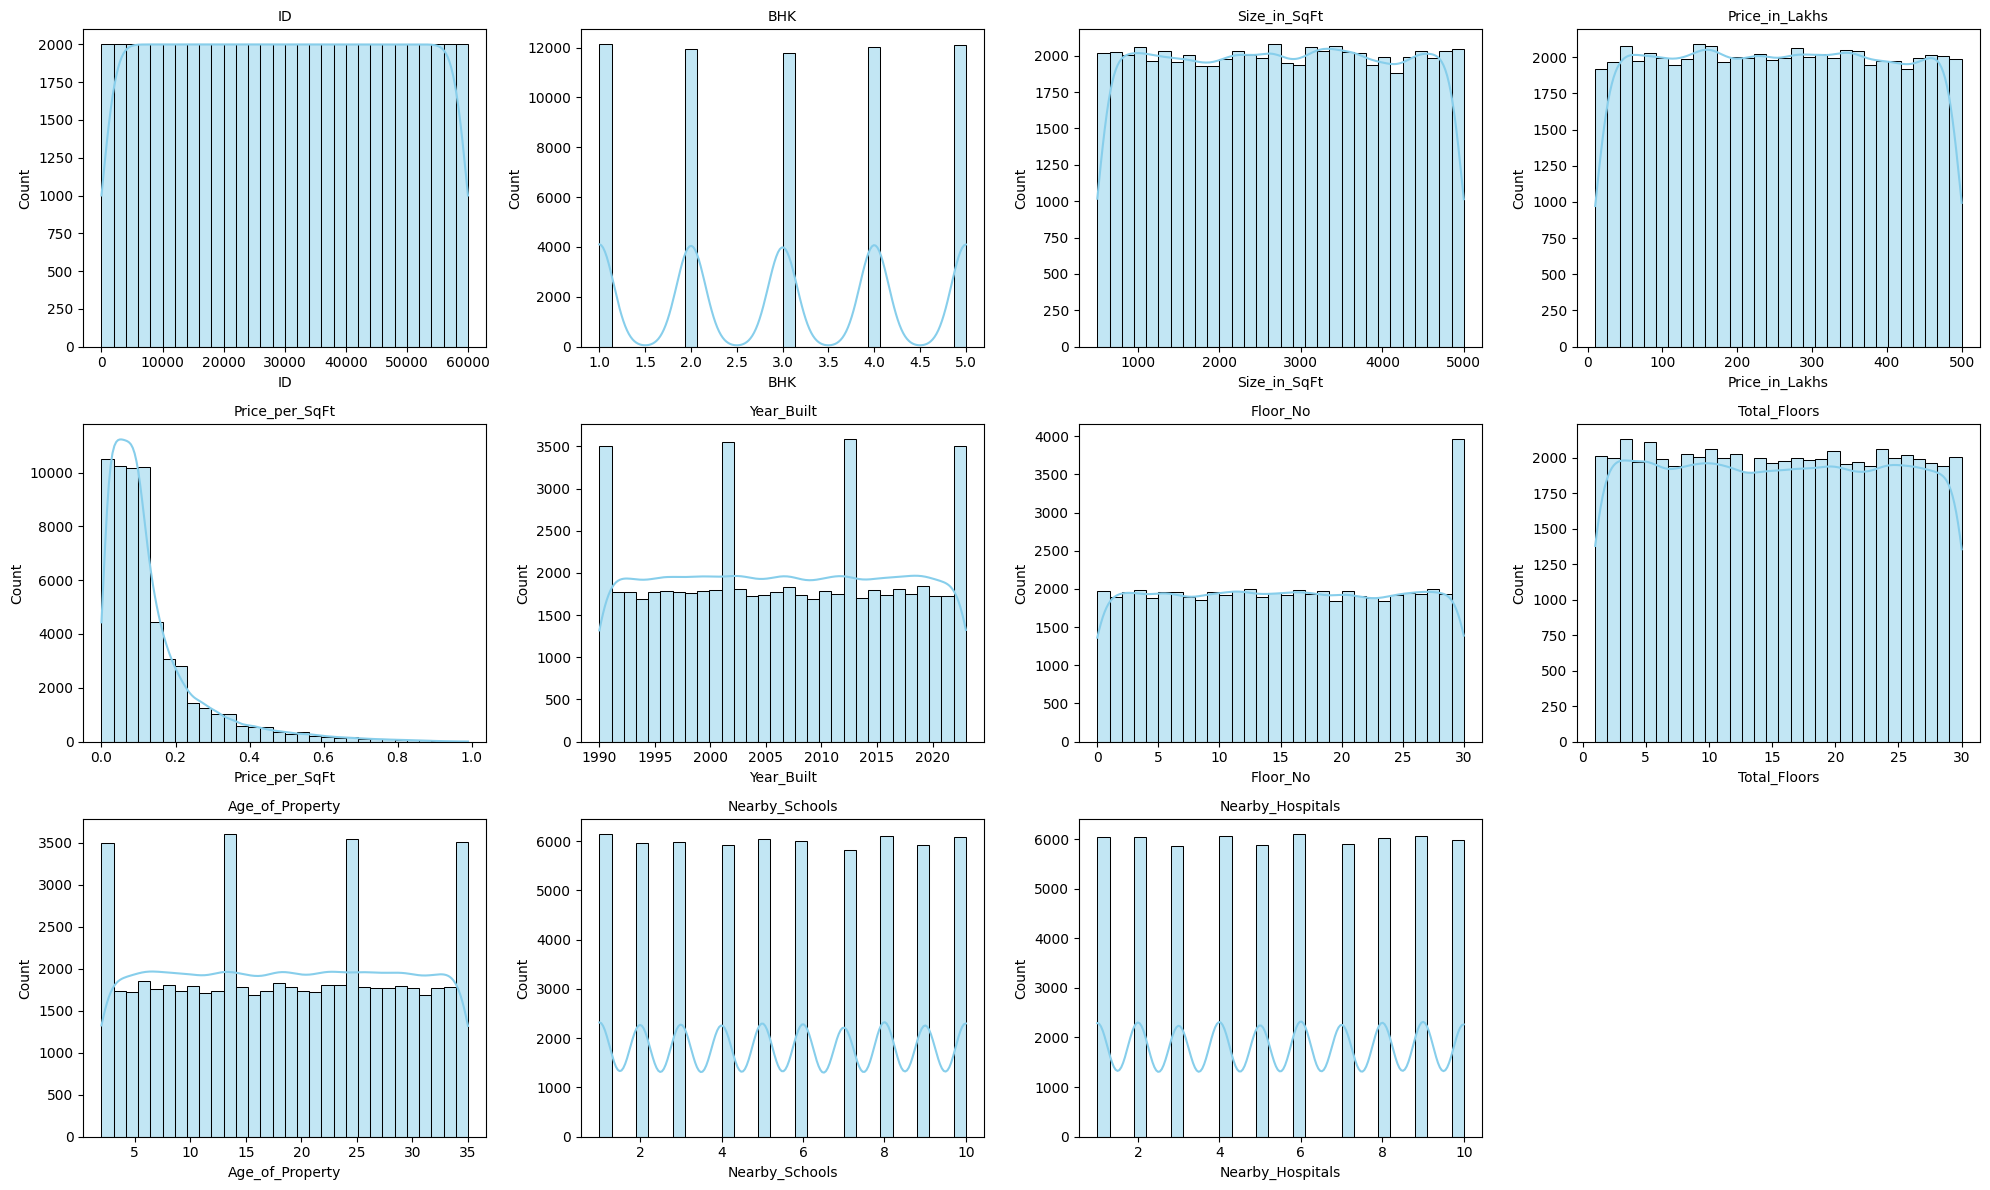

<Figure size 640x480 with 0 Axes>

In [19]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Plot each numeric column
n_cols = 4   # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="skyblue")
    axes[i].set_title(f'{col}', fontsize=10)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
plt.savefig("numeric_columns_distribution.png",)  # saves as PNG
plt.show()

Categorical colimns

In [20]:
df.describe(include=["object","category"])

,State,City,Locality,Property_Type,Furnished_Status,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
count,60000,60000,60000,60000,60000,60000,60000,60000,60000,60000,60000,60000
unique,20,42,500,3,3,3,2,2,325,4,3,2
top,Andhra Pradesh,Vijayawada,Locality_296,Independent House,Furnished,Low,No,Yes,Pool,East,Owner,Ready_to_Move
freq,3109,1585,148,20098,20041,20088,30047,30008,2427,15097,20079,30069


## 6. Outlier detection with IQR:

In [21]:
import pandas as pd

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    outlier_report[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    }

# Convert to DataFrame for readability
report_df = pd.DataFrame(outlier_report).T
print(report_df)

                         Q1          Q3         IQR  Lower Bound  Upper Bound  \
ID                15000.750  45000.2500  29999.5000 -29998.50000  89999.50000   
BHK                   2.000      4.0000      2.0000     -1.00000      7.00000   
Size_in_SqFt       1620.000   3868.0000   2248.0000  -1752.00000   7240.00000   
Price_in_Lakhs      132.965    375.9925    243.0275   -231.57625    740.53375   
Price_per_SqFt        0.050      0.1600      0.1100     -0.11500      0.32500   
Year_Built         1998.000   2015.0000     17.0000   1972.50000   2040.50000   
Floor_No              7.000     23.0000     16.0000    -17.00000     47.00000   
Total_Floors          8.000     23.0000     15.0000    -14.50000     45.50000   
Age_of_Property      10.000     27.0000     17.0000    -15.50000     52.50000   
Nearby_Schools        3.000      8.0000      5.0000     -4.50000     15.50000   
Nearby_Hospitals      3.000      8.0000      5.0000     -4.50000     15.50000   

                  Outlier C

## 7. Visualizations (all five types required):



*  A line plot












*  A bar chart




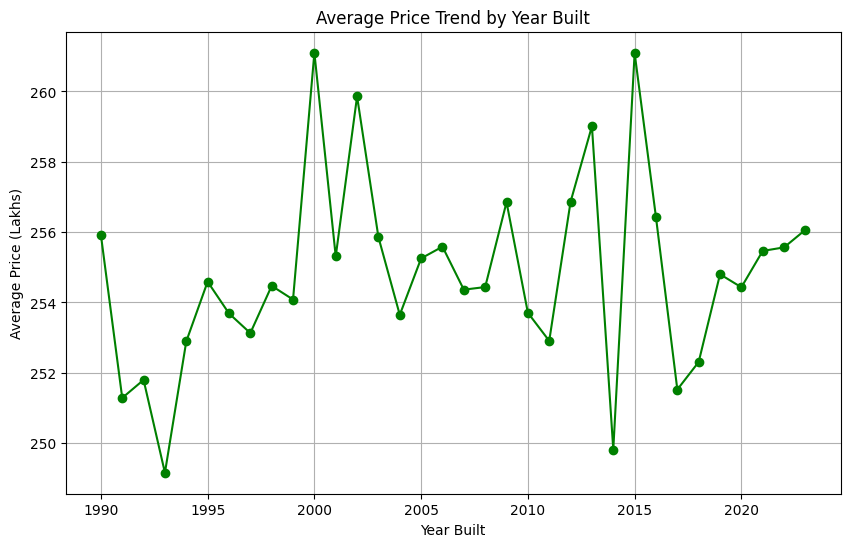

In [22]:
# Step 1: Group by year and compute average price
yearly_avg = df.groupby('Year_Built')['Price_in_Lakhs'].mean().sort_index()

# Step 2: Plot the average price trend
plt.figure(figsize=(10,6))
plt.plot(yearly_avg.index, yearly_avg.values, color='green', marker='o')

# Step 3: Add labels and title
plt.title("Average Price Trend by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average Price (Lakhs)")
plt.grid(True)
plt.show()


/tmp/ipykernel_595/1639832871.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df.groupby('State')['Price_in_Lakhs'].mean()


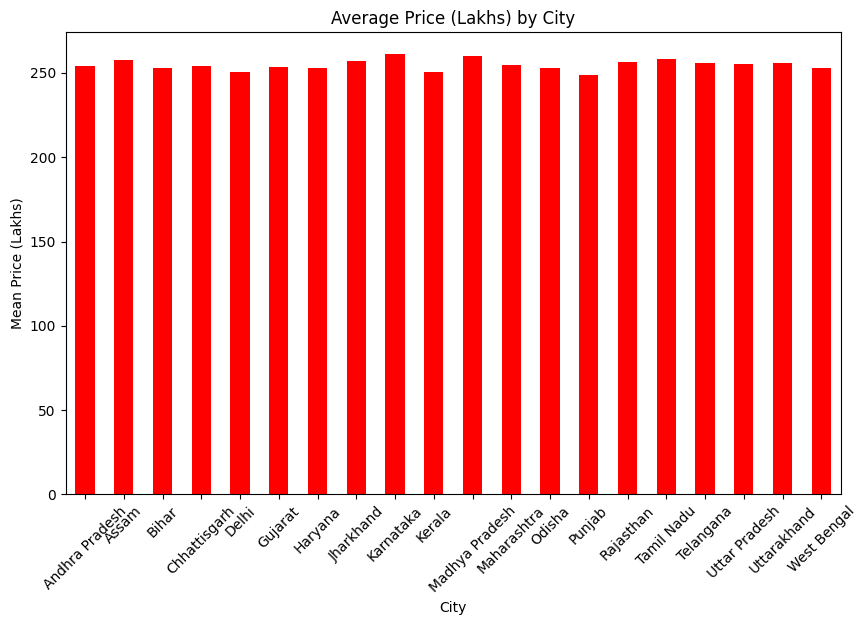

In [23]:
# Example: numeric column = 'Price_in_Lakhs', categorical column = 'City'
mean_values = df.groupby('State')['Price_in_Lakhs'].mean()

# Plot using df.plot.bar()
mean_values.plot.bar(color='red', figsize=(10,6))

# Add title and axis labels
plt.title("Average Price (Lakhs) by City")
plt.xlabel("City")
plt.ylabel("Mean Price (Lakhs)")
plt.xticks(rotation=45)  # rotate labels for readability
plt.show()



*  A histogram




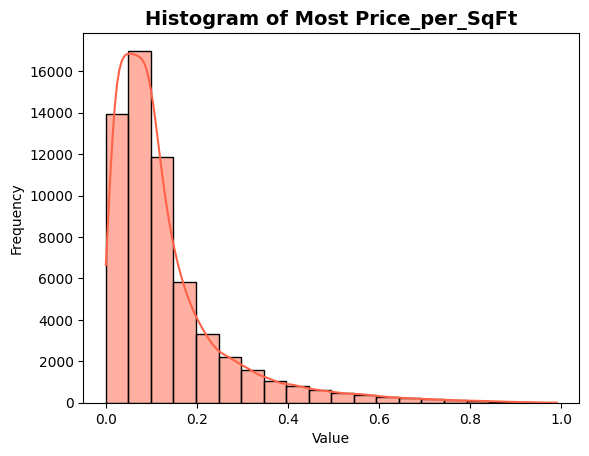

In [27]:
sns.histplot(df['Price_per_SqFt'], bins=20, kde=True, color="tomato")

plt.title("Histogram of Most Price_per_SqFt", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()



*  A scatter plot




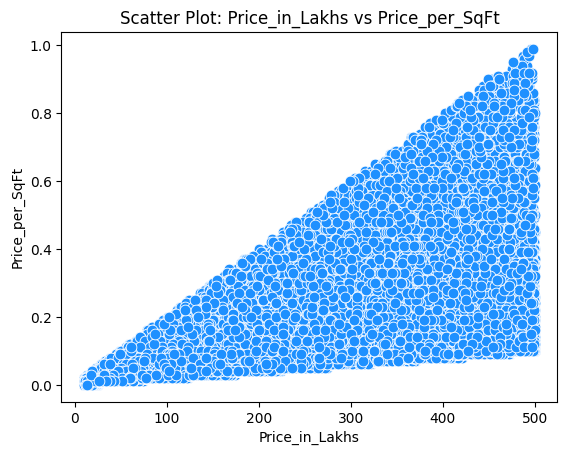

In [28]:
# Example: numeric columns = 'income' and 'spending'
sns.scatterplot(x=df['Price_in_Lakhs'], y=df['Price_per_SqFt'], color="dodgerblue", s=60)

plt.title("Scatter Plot: Price_in_Lakhs vs Price_per_SqFt")
plt.xlabel("Price_in_Lakhs")
plt.ylabel("Price_per_SqFt")
plt.show()



*  A box plot




/tmp/ipykernel_595/353920561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Property_Type'], y=df['Price_in_Lakhs'], palette="Set2",)


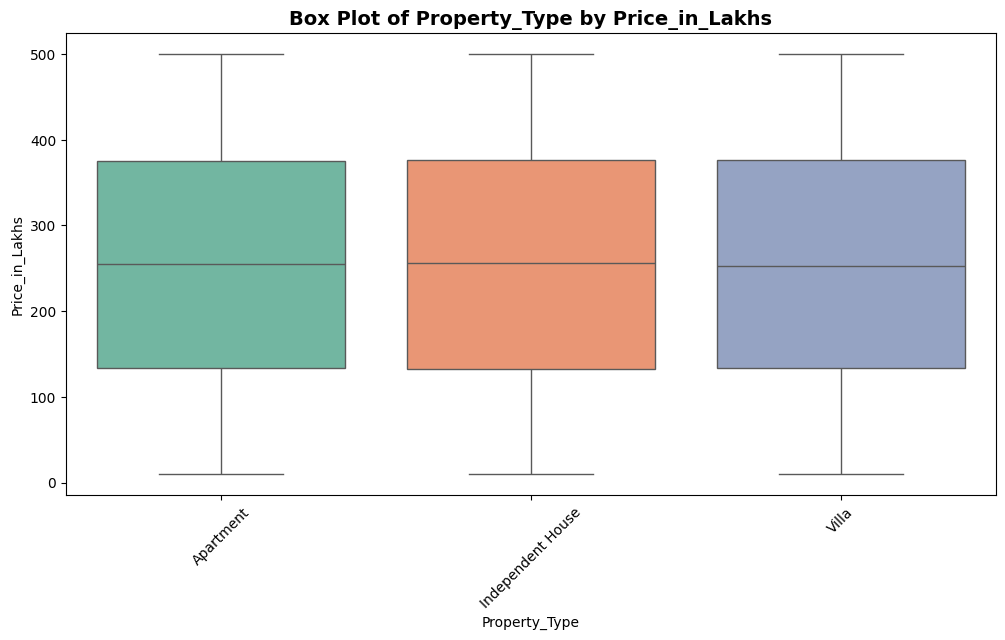

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
# Example: numeric column = 'sales', categorical column = 'region'
sns.boxplot(x=df['Property_Type'], y=df['Price_in_Lakhs'], palette="Set2",)

plt.title("Box Plot of Property_Type by Price_in_Lakhs", fontsize=14, fontweight='bold')
plt.xlabel("Property_Type")
plt.ylabel("Price_in_Lakhs")
plt.xticks(rotation=45)
plt.show()

## 8. Correlation heat map:

In [30]:
df.corr(numeric_only=True)

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
ID,1.000000,0.002175,-0.001711,0.003776,0.001443,0.004803,0.000034,0.005726,-0.004803,-0.005090,-0.000085
BHK,0.002175,1.000000,-0.001784,-0.001571,0.000527,0.002561,0.004386,-0.004001,-0.002561,-0.001867,-0.000970
Size_in_SqFt,-0.001711,-0.001784,1.000000,-0.006713,-0.617723,0.010277,0.001058,-0.004655,-0.010277,0.004320,0.003309
Price_in_Lakhs,0.003776,-0.001571,-0.006713,1.000000,0.555521,0.003961,0.001692,-0.009434,-0.003961,-0.005623,-0.005776
Price_per_SqFt,0.001443,0.000527,-0.617723,0.555521,1.000000,-0.003254,-0.004228,-0.000941,0.003254,-0.002660,-0.005021
Year_Built,0.004803,0.002561,0.010277,0.003961,-0.003254,1.000000,-0.000364,0.006332,-1.000000,0.004300,-0.000630
Floor_No,0.000034,0.004386,0.001058,0.001692,-0.004228,-0.000364,1.000000,0.002195,0.000364,0.004041,-0.004785
Total_Floors,0.005726,-0.004001,-0.004655,-0.009434,-0.000941,0.006332,0.002195,1.000000,-0.006332,-0.004725,-0.010292
Age_of_Property,-0.004803,-0.002561,-0.010277,-0.003961,0.003254,-1.000000,0.000364,-0.006332,1.000000,-0.004300,0.000630
Nearby_Schools,-0.005090,-0.001867,0.004320,-0.005623,-0.002660,0.004300,0.004041,-0.004725,-0.004300,1.000000,-0.002972


<Axes: >

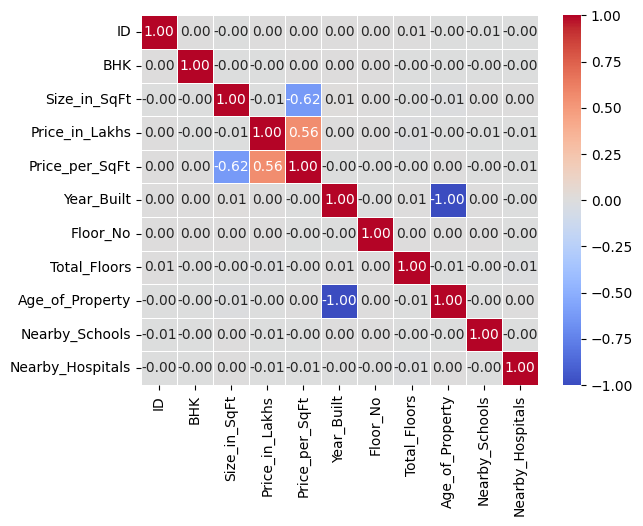

In [31]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

## 9(a).  Imputation strategy comparison.

In [32]:
# Step 1: Identify skewness for numeric columns
from scipy.stats import skew
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
skew_values = df[numeric_cols].apply(lambda x: skew(x.dropna()))

# Step 2: Pick top 2 columns with highest absolute skewness
top2_cols = skew_values.abs().sort_values(ascending=False).head(2).index
print("Top 2 skewed columns:", top2_cols.tolist())

# Step 3: Compute mean and median for each column (before imputation)
for col in top2_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, skew={skew_values[col]:.2f}")

# Step 4: Choose imputation strategy based on skewness direction
# Positively skewed → median; Negatively skewed → median (since mean is pulled away)
for col in top2_cols:
    chosen_val = df[col].median()
    df[col] = df[col].fillna(chosen_val)

Top 2 skewed columns: ['Price_per_SqFt', 'Total_Floors']
Price_per_SqFt: mean=0.13, median=0.09, skew=2.30
Total_Floors: mean=15.44, median=15.00, skew=0.01


9(b).  Spearman rank correlation.

In [33]:
# Step 1: Pearson correlation (linear relationships)
pearson_corr = df.corr(method='pearson',	numeric_only=True)

# Step 2: Spearman correlation (rank-based monotonic relationships)
spearman_corr = df.corr(method='spearman', numeric_only=True)

# Step 3: Absolute difference matrix
diff_matrix = (spearman_corr - pearson_corr).abs()

# Step 4: Extract top 3 pairs with largest differences
pairs = []
cols = df.select_dtypes(include=['int64','float64']).columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], diff_matrix.loc[cols[i], cols[j]]))

top3 = sorted(pairs, key=lambda x: x[2], reverse=True)[:3]

# Step 5: Print results
print("Pearson Correlation Matrix:\n", pearson_corr)
print("\nSpearman Correlation Matrix:\n", spearman_corr)

print("\nTop 3 pairs with largest |Spearman - Pearson| difference:")
for c1, c2, diff in top3:
    print(f"{c1} vs {c2}: |Spearman-Pearson|={diff:.3f}, "
          f"Pearson={pearson_corr.loc[c1,c2]:.3f}, Spearman={spearman_corr.loc[c1,c2]:.3f}")

Pearson Correlation Matrix:
                         ID       BHK  Size_in_SqFt  Price_in_Lakhs  \
ID                1.000000  0.002175     -0.001711        0.003776   
BHK               0.002175  1.000000     -0.001784       -0.001571   
Size_in_SqFt     -0.001711 -0.001784      1.000000       -0.006713   
Price_in_Lakhs    0.003776 -0.001571     -0.006713        1.000000   
Price_per_SqFt    0.001443  0.000527     -0.617723        0.555521   
Year_Built        0.004803  0.002561      0.010277        0.003961   
Floor_No          0.000034  0.004386      0.001058        0.001692   
Total_Floors      0.005726 -0.004001     -0.004655       -0.009434   
Age_of_Property  -0.004803 -0.002561     -0.010277       -0.003961   
Nearby_Schools   -0.005090 -0.001867      0.004320       -0.005623   
Nearby_Hospitals -0.000085 -0.000970      0.003309       -0.005776   

                  Price_per_SqFt  Year_Built  Floor_No  Total_Floors  \
ID                      0.001443    0.004803  0.000034    

## 9(c). Grouped aggregation.

In [34]:
grouped_stats = df.groupby("Property_Type")["Price_in_Lakhs"].agg(['mean', 'std', 'count'])

print(grouped_stats)

                         mean         std  count
Property_Type                                   
Apartment          254.671684  140.925408  19901
Independent House  255.137776  141.450321  20098
Villa              254.628124  140.811277  20001


/tmp/ipykernel_595/2534667929.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stats = df.groupby("Property_Type")["Price_in_Lakhs"].agg(['mean', 'std', 'count'])


## 10. Save the clean dataset

In [35]:
df.drop(columns=['ID'], inplace=True)

df.drop(columns=['Price_per_SqFt','Year_Built',"Locality"], inplace=True)

In [36]:
df.to_csv("cleaned_Housing_data.csv", index=False)